In [12]:
import pandas as pd
import numpy as np

df= pd.read_csv(r'C:\Users\nihal\Downloads\H1.csv')
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [13]:
import warnings
warnings.filterwarnings('ignore')

In [14]:
df.describe()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,BookingChanges,DaysInWaitingList,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests
count,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.00000
mean,0.277634,92.675686,2016.121443,27.140864,15.821243,1.189815,3.128732,1.867149,0.128682,0.013904,0.044383,0.101722,0.146455,0.287968,0.527758,94.952930,0.138068,0.61977
std,0.447837,97.285315,0.722347,14.005441,8.883708,1.147812,2.461329,0.697285,0.445195,0.118998,0.205948,1.335115,1.001955,0.726548,7.428580,61.442418,0.351001,0.81393
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.00000
25%,0.000000,10.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.00000
50%,0.000000,57.000000,2016.000000,28.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,75.000000,0.000000,0.00000
75%,1.000000,155.000000,2017.000000,38.000000,24.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,125.000000,0.000000,1.00000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,2.000000,1.000000,26.000000,30.000000,17.000000,185.000000,508.000000,8.000000,5.00000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40060 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   40060 non-null  int64  
 1   LeadTime                     40060 non-null  int64  
 2   ArrivalDateYear              40060 non-null  int64  
 3   ArrivalDateMonth             40060 non-null  object 
 4   ArrivalDateWeekNumber        40060 non-null  int64  
 5   ArrivalDateDayOfMonth        40060 non-null  int64  
 6   StaysInWeekendNights         40060 non-null  int64  
 7   StaysInWeekNights            40060 non-null  int64  
 8   Adults                       40060 non-null  int64  
 9   Children                     40060 non-null  int64  
 10  Babies                       40060 non-null  int64  
 11  Meal                         40060 non-null  object 
 12  Country                      39596 non-null  object 
 13  MarketSegment   

In [16]:
df= df.apply(lambda x: x.str.strip() if x.dtype== "object" else x)
null_values=['NULL','null','NaN','nan','None','']
df=df.replace(null_values,np.nan)

df.isnull().sum()

IsCanceled                         0
LeadTime                           0
ArrivalDateYear                    0
ArrivalDateMonth                   0
ArrivalDateWeekNumber              0
ArrivalDateDayOfMonth              0
StaysInWeekendNights               0
StaysInWeekNights                  0
Adults                             0
Children                           0
Babies                             0
Meal                               0
Country                          464
MarketSegment                      0
DistributionChannel                0
IsRepeatedGuest                    0
PreviousCancellations              0
PreviousBookingsNotCanceled        0
ReservedRoomType                   0
AssignedRoomType                   0
BookingChanges                     0
DepositType                        0
Agent                           8209
Company                        36952
DaysInWaitingList                  0
CustomerType                       0
ADR                                0
R

In [17]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent=(missing/len(df))*100

pd.DataFrame({
    "Missing Count":missing,
    "Missing %":missing_percent
})

,Missing Count,Missing %
Company,36952,92.241638
Agent,8209,20.491762
Country,464,1.158263
ArrivalDateMonth,0,0.000000
ArrivalDateWeekNumber,0,0.000000
LeadTime,0,0.000000
IsCanceled,0,0.000000
StaysInWeekendNights,0,0.000000
StaysInWeekNights,0,0.000000
Children,0,0.000000


In [18]:
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40060 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   40060 non-null  int64  
 1   LeadTime                     40060 non-null  int64  
 2   ArrivalDateYear              40060 non-null  int64  
 3   ArrivalDateMonth             40060 non-null  object 
 4   ArrivalDateWeekNumber        40060 non-null  int64  
 5   ArrivalDateDayOfMonth        40060 non-null  int64  
 6   StaysInWeekendNights         40060 non-null  int64  
 7   StaysInWeekNights            40060 non-null  int64  
 8   Adults                       40060 non-null  int64  
 9   Children                     40060 non-null  int64  
 10  Babies                       40060 non-null  int64  
 11  Meal                         40060 non-null  object 
 12  Country                      39596 non-null  object 
 13  MarketSegment   

In [20]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [21]:
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,240,223,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,240,223,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,240,223,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,223,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,223,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40060 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   40060 non-null  int64  
 1   LeadTime                     40060 non-null  int64  
 2   ArrivalDateYear              40060 non-null  int64  
 3   ArrivalDateMonth             40060 non-null  object 
 4   ArrivalDateWeekNumber        40060 non-null  int64  
 5   ArrivalDateDayOfMonth        40060 non-null  int64  
 6   StaysInWeekendNights         40060 non-null  int64  
 7   StaysInWeekNights            40060 non-null  int64  
 8   Adults                       40060 non-null  int64  
 9   Children                     40060 non-null  int64  
 10  Babies                       40060 non-null  int64  
 11  Meal                         40060 non-null  object 
 12  Country                      40060 non-null  object 
 13  MarketSegment   

In [23]:
df=df.drop_duplicates()

In [24]:
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,240,223,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,240,223,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,240,223,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,223,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,223,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33949 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   33949 non-null  int64  
 1   LeadTime                     33949 non-null  int64  
 2   ArrivalDateYear              33949 non-null  int64  
 3   ArrivalDateMonth             33949 non-null  object 
 4   ArrivalDateWeekNumber        33949 non-null  int64  
 5   ArrivalDateDayOfMonth        33949 non-null  int64  
 6   StaysInWeekendNights         33949 non-null  int64  
 7   StaysInWeekNights            33949 non-null  int64  
 8   Adults                       33949 non-null  int64  
 9   Children                     33949 non-null  int64  
 10  Babies                       33949 non-null  int64  
 11  Meal                         33949 non-null  object 
 12  Country                      33949 non-null  object 
 13  MarketSegment        

In [26]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

In [27]:
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,240,223,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,240,223,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,240,223,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,223,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,223,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [28]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33949 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   iscanceled                   33949 non-null  int64  
 1   leadtime                     33949 non-null  int64  
 2   arrivaldateyear              33949 non-null  int64  
 3   arrivaldatemonth             33949 non-null  object 
 4   arrivaldateweeknumber        33949 non-null  int64  
 5   arrivaldatedayofmonth        33949 non-null  int64  
 6   staysinweekendnights         33949 non-null  int64  
 7   staysinweeknights            33949 non-null  int64  
 8   adults                       33949 non-null  int64  
 9   children                     33949 non-null  int64  
 10  babies                       33949 non-null  int64  
 11  meal                         33949 non-null  object 
 12  country                      33949 non-null  object 
 13  marketsegment        

In [30]:
df['reservationstatusdate'] = pd.to_datetime(
    df['reservationstatusdate'],
    format='%Y-%m-%d',
    errors='coerce'
)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33949 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   iscanceled                   33949 non-null  int64         
 1   leadtime                     33949 non-null  int64         
 2   arrivaldateyear              33949 non-null  int64         
 3   arrivaldatemonth             33949 non-null  object        
 4   arrivaldateweeknumber        33949 non-null  int64         
 5   arrivaldatedayofmonth        33949 non-null  int64         
 6   staysinweekendnights         33949 non-null  int64         
 7   staysinweeknights            33949 non-null  int64         
 8   adults                       33949 non-null  int64         
 9   children                     33949 non-null  int64         
 10  babies                       33949 non-null  int64         
 11  meal                         33949 non-null  o

In [32]:
df['totalstay']= df['staysinweeknights']+df['staysinweekendnights']

In [33]:
df['res_year'] = df['reservationstatusdate'].dt.year
df['res_month'] = df['reservationstatusdate'].dt.month
df['res_day'] = df['reservationstatusdate'].dt.day
df['res_weekday'] = df['reservationstatusdate'].dt.weekday

In [34]:
df['pricepernight'] = df['adr'] / (df['staysinweekendnights'] + 1)

In [35]:
df.head()

,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,requiredcarparkingspaces,totalofspecialrequests,reservationstatus,reservationstatusdate,totalstay,res_year,res_month,res_day,res_weekday,pricepernight
0,0,342,2015,July,27,1,0,0,2,0,...,0,0,Check-Out,2015-07-01,0,2015,7,1,2,0.0
1,0,737,2015,July,27,1,0,0,2,0,...,0,0,Check-Out,2015-07-01,0,2015,7,1,2,0.0
2,0,7,2015,July,27,1,0,1,1,0,...,0,0,Check-Out,2015-07-02,1,2015,7,2,3,75.0
3,0,13,2015,July,27,1,0,1,1,0,...,0,0,Check-Out,2015-07-02,1,2015,7,2,3,75.0
4,0,14,2015,July,27,1,0,2,2,0,...,0,1,Check-Out,2015-07-03,2,2015,7,3,4,98.0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33949 entries, 0 to 40059
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   iscanceled                   33949 non-null  int64         
 1   leadtime                     33949 non-null  int64         
 2   arrivaldateyear              33949 non-null  int64         
 3   arrivaldatemonth             33949 non-null  object        
 4   arrivaldateweeknumber        33949 non-null  int64         
 5   arrivaldatedayofmonth        33949 non-null  int64         
 6   staysinweekendnights         33949 non-null  int64         
 7   staysinweeknights            33949 non-null  int64         
 8   adults                       33949 non-null  int64         
 9   children                     33949 non-null  int64         
 10  babies                       33949 non-null  int64         
 11  meal                         33949 non-null  o

In [37]:
df_cleanednegative= df[df['adr']>=0]

In [38]:
df_cleanednegative.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33948 entries, 0 to 40059
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   iscanceled                   33948 non-null  int64         
 1   leadtime                     33948 non-null  int64         
 2   arrivaldateyear              33948 non-null  int64         
 3   arrivaldatemonth             33948 non-null  object        
 4   arrivaldateweeknumber        33948 non-null  int64         
 5   arrivaldatedayofmonth        33948 non-null  int64         
 6   staysinweekendnights         33948 non-null  int64         
 7   staysinweeknights            33948 non-null  int64         
 8   adults                       33948 non-null  int64         
 9   children                     33948 non-null  int64         
 10  babies                       33948 non-null  int64         
 11  meal                         33948 non-null  o

In [39]:
df_cleanednegative['adr'].max()

508.0

In [40]:
Q1 = df_cleanednegative['adr'].quantile(0.25)
Q3 = df_cleanednegative['adr'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower, "Upper:", upper)

Lower: -72.39999999999999 Upper: 258.0


In [41]:
upper = df_cleanednegative['adr'].quantile(0.99)
lower = df_cleanednegative['adr'].quantile(0.01)

df_cleanednegative['adr'] = df_cleanednegative['adr'].clip(lower, upper)

In [42]:
df_cleanednegative['adr_log'] = np.log1p(df_cleanednegative['adr'])

In [43]:
df_cleanednegative

,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,totalofspecialrequests,reservationstatus,reservationstatusdate,totalstay,res_year,res_month,res_day,res_weekday,pricepernight,adr_log
0,0,342,2015,July,27,1,0,0,2,0,...,0,Check-Out,2015-07-01,0,2015,7,1,2,0.000000,0.000000
1,0,737,2015,July,27,1,0,0,2,0,...,0,Check-Out,2015-07-01,0,2015,7,1,2,0.000000,0.000000
2,0,7,2015,July,27,1,0,1,1,0,...,0,Check-Out,2015-07-02,1,2015,7,2,3,75.000000,4.330733
3,0,13,2015,July,27,1,0,1,1,0,...,0,Check-Out,2015-07-02,1,2015,7,2,3,75.000000,4.330733
4,0,14,2015,July,27,1,0,2,2,0,...,1,Check-Out,2015-07-03,2,2015,7,3,4,98.000000,4.595120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40055,0,212,2017,August,35,31,2,8,2,1,...,0,Check-Out,2017-09-10,10,2017,9,10,6,29.916667,4.508108
40056,0,169,2017,August,35,30,2,9,2,0,...,1,Check-Out,2017-09-10,11,2017,9,10,6,67.423333,5.314535
40057,0,204,2017,August,35,29,4,10,2,0,...,3,Check-Out,2017-09-12,14,2017,9,12,1,30.714000,5.040647
40058,0,211,2017,August,35,31,4,10,2,0,...,1,Check-Out,2017-09-14,14,2017,9,14,3,22.560000,4.734443


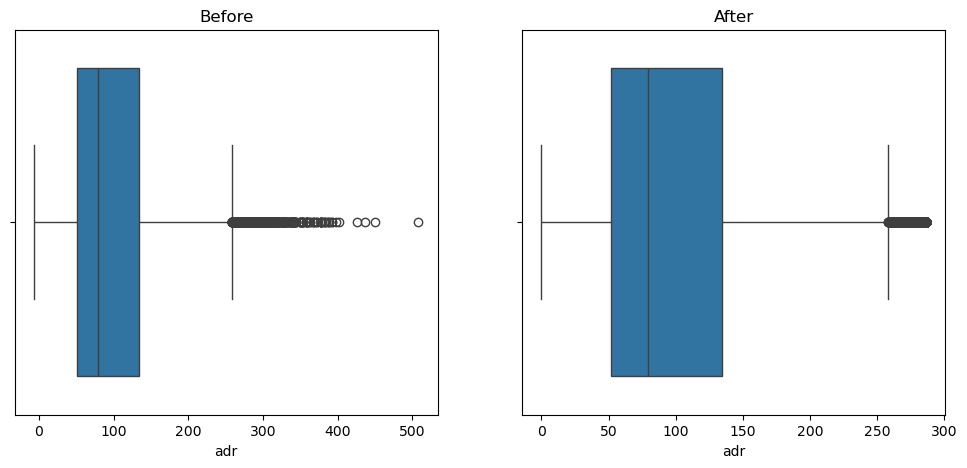

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['adr'])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(x=df_cleanednegative['adr'])
plt.title("After")

plt.show()

In [45]:
df_cleanednegative.to_csv('cleaned2_data.csv',index=False)